# N-CMAPSS DS01 -- Modeling

Two framings, both baselined with gradient boosting (XGBoost) on cycle-level features
(see `src/features.py`):

1. **RUL regression** -- predict remaining useful life in cycles
2. **Binary failure classification** -- predict whether the engine fails within the next
   20 cycles

Unit-level split (`src/splits.py`): train on units {1,2,3}, model-select / tune on
{4,5,6}, report final numbers on the held-out test units {7,8,9,10} -- NASA's own
unit-disjoint test split, touched only for the numbers in this notebook.

This notebook calls the same training code as `src/train.py` directly, so results here
always match what running that script produces.

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import RocCurveDisplay, precision_recall_curve

from evaluate import phm_score
from features import feature_columns, split_xy
from splits import TEST_UNITS, TRAIN_UNITS, VAL_UNITS
from train import _prepare, _role, train_classifier, train_rul_model

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

In [2]:
df = _prepare()
role = df["unit"].map(_role)
df["split"] = role.values
print(df.shape)
df["split"].value_counts()

(894, 121)


split
test     341
val      278
train    275
Name: count, dtype: int64

## RUL regression

In [3]:
rul_model, rul_reports = train_rul_model(df)
print(f"best_iteration = {rul_model.best_iteration}")
pd.DataFrame(rul_reports).T

best_iteration = 91


,rmse,mae,phm_score_sum,phm_score_mean,n_samples
train,1.783739,1.326627,36.274925,0.131909,275.0
val,6.748576,5.228189,186.168629,0.669671,278.0
test,10.770590,9.087172,661.448811,1.939733,341.0


### Predicted vs. actual RUL, and residuals

Predictions are tightest near end-of-life (low RUL), which is exactly where a
maintenance system needs them to be tightest -- early-life RUL is inherently harder to
pin down since degradation hasn't diverged from the healthy baseline yet.

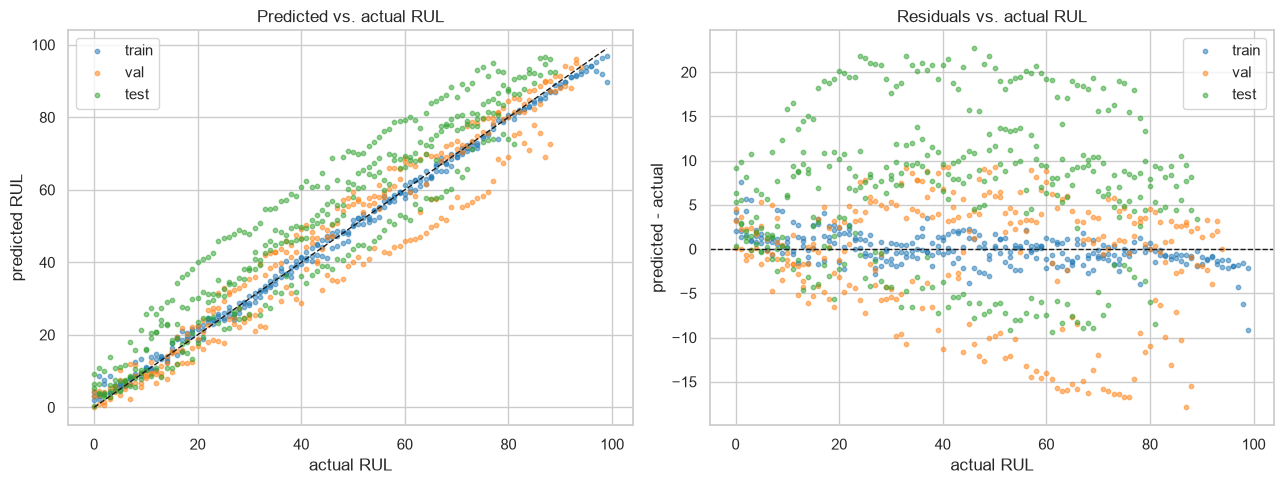

In [4]:
X, y, _ = split_xy(df)
df["rul_pred"] = rul_model.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {"train": "tab:blue", "val": "tab:orange", "test": "tab:green"}
for split, color in colors.items():
    sub = df[df["split"] == split]
    axes[0].scatter(sub["RUL"], sub["rul_pred"], s=10, alpha=0.5, color=color, label=split)
    axes[1].scatter(sub["RUL"], sub["rul_pred"] - sub["RUL"], s=10, alpha=0.5, color=color, label=split)
lims = [0, df["RUL"].max()]
axes[0].plot(lims, lims, "k--", linewidth=1)
axes[0].set_xlabel("actual RUL"); axes[0].set_ylabel("predicted RUL"); axes[0].set_title("Predicted vs. actual RUL")
axes[1].axhline(0, color="k", linewidth=1, linestyle="--")
axes[1].set_xlabel("actual RUL"); axes[1].set_ylabel("predicted - actual"); axes[1].set_title("Residuals vs. actual RUL")
axes[0].legend(); axes[1].legend()
plt.tight_layout()
plt.show()

### PHM08 asymmetric score

The standard C-MAPSS-challenge scoring function penalizes over-predicting remaining life
(telling an operator an engine has more life left than it actually does) more heavily
than under-predicting it. Distribution of per-sample scores on the test set:

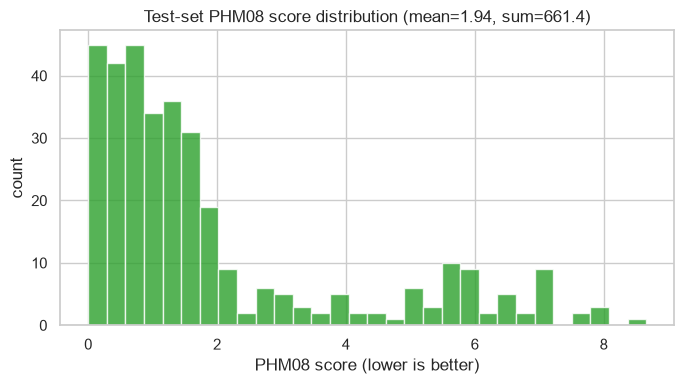

In [5]:
test_mask = df["split"] == "test"
test_scores = phm_score(df.loc[test_mask, "RUL"], df.loc[test_mask, "rul_pred"])
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(test_scores, bins=30, color="tab:green", alpha=0.8)
ax.set_xlabel("PHM08 score (lower is better)"); ax.set_ylabel("count")
ax.set_title(f"Test-set PHM08 score distribution (mean={test_scores.mean():.2f}, sum={test_scores.sum():.1f})")
plt.tight_layout()
plt.show()

### Feature importance -- RUL regressor

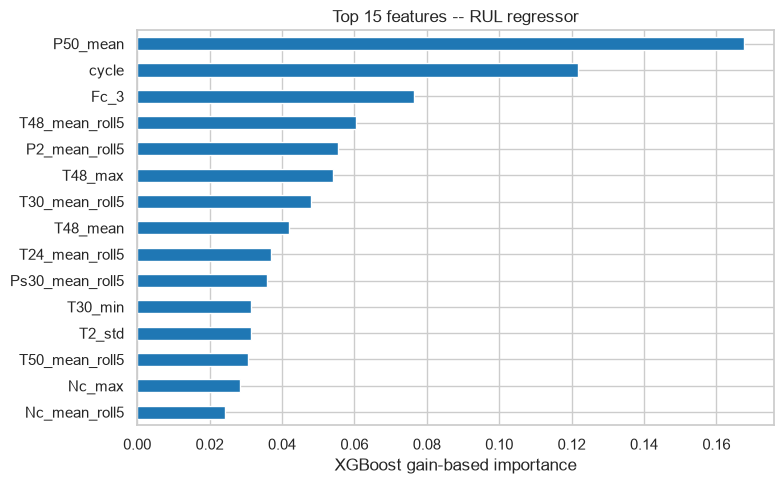

In [6]:
importances = pd.Series(rul_model.feature_importances_, index=feature_columns()).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 5))
importances.iloc[::-1].plot.barh(ax=ax, color="tab:blue")
ax.set_xlabel("XGBoost gain-based importance")
ax.set_title("Top 15 features -- RUL regressor")
plt.tight_layout()
plt.show()

## Binary failure classification

Target: fails within 20 cycles (`src/features.py::FAILURE_HORIZON`). The decision
threshold is tuned on the validation set (maximizing F1) rather than left at the default
0.5, since the raw probability output is not well-calibrated with this little training
data -- see `src/evaluate.py::select_threshold`.

In [7]:
clf_model, clf_reports = train_classifier(df)
threshold = clf_reports["decision_threshold"]
print(f"best_iteration = {clf_model.best_iteration}, decision_threshold = {threshold}")
pd.DataFrame({k: v for k, v in clf_reports.items() if k != "decision_threshold"}).T

best_iteration = 62, decision_threshold = 0.25


,confusion_matrix,precision,recall,f1,n_samples,n_positive,roc_auc
train,"{'tn': 212, 'fp': 0, 'fn': 0, 'tp': 63}",1.0,1.0,1.0,275,63,1.0
val,"{'tn': 204, 'fp': 11, 'fn': 6, 'tp': 57}",0.838235,0.904762,0.870229,278,63,0.984791
test,"{'tn': 249, 'fp': 8, 'fn': 31, 'tp': 53}",0.868852,0.630952,0.731034,341,84,0.965397


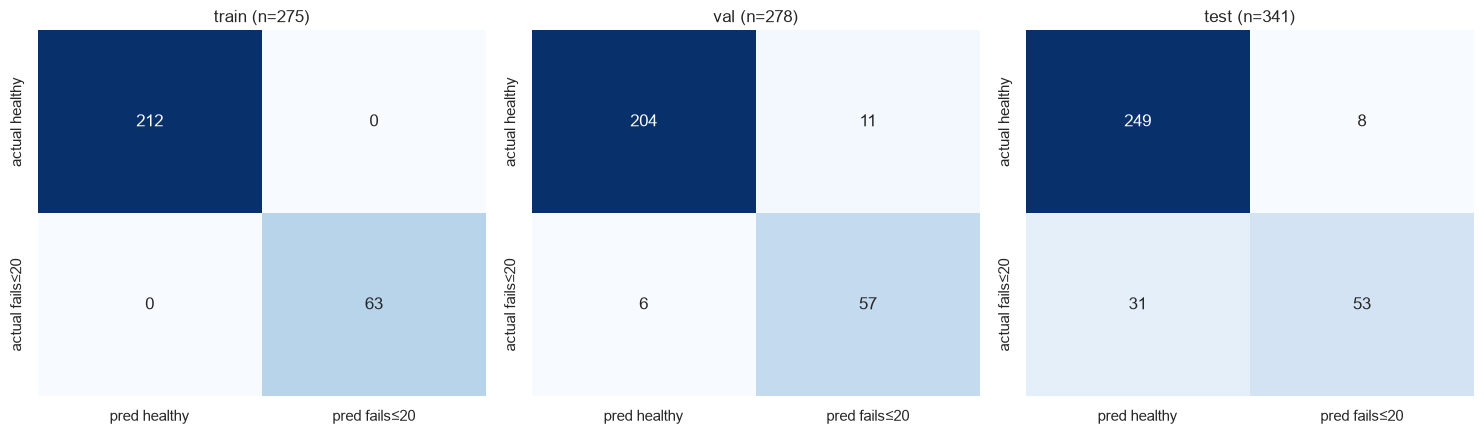

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, split in zip(axes, ("train", "val", "test")):
    cm = clf_reports[split]["confusion_matrix"]
    mat = np.array([[cm["tn"], cm["fp"]], [cm["fn"], cm["tp"]]])
    sns.heatmap(mat, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["pred healthy", "pred fails\u226420"],
                yticklabels=["actual healthy", "actual fails\u226420"], ax=ax)
    ax.set_title(f"{split} (n={clf_reports[split]['n_samples']})")
plt.tight_layout()
plt.show()

### ROC and precision/recall vs. threshold

The ROC curve shows ranking quality is stable across splits (AUC ~0.97-0.98); the
precision/recall-vs-threshold plot shows why 0.5 was a poor default and where the tuned
threshold sits.

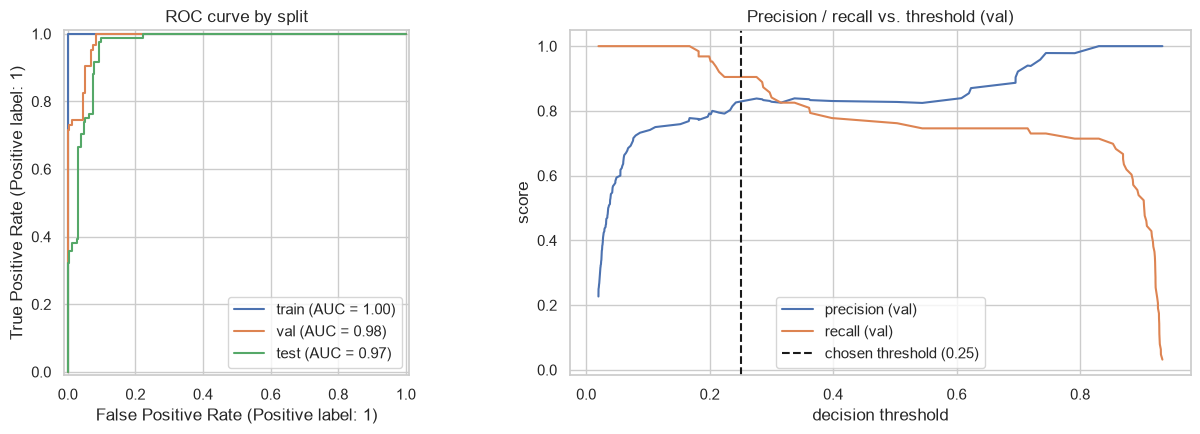

In [9]:
_, _, y_fails = split_xy(df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for split, color in colors.items():
    mask = df["split"] == split
    proba = clf_model.predict_proba(X[mask])[:, 1]
    RocCurveDisplay.from_predictions(y_fails[mask], proba, ax=axes[0], name=split)

val_mask = df["split"] == "val"
val_proba = clf_model.predict_proba(X[val_mask])[:, 1]
prec, rec, thresh = precision_recall_curve(y_fails[val_mask], val_proba)
axes[1].plot(thresh, prec[:-1], label="precision (val)")
axes[1].plot(thresh, rec[:-1], label="recall (val)")
axes[1].axvline(threshold, color="k", linestyle="--", label=f"chosen threshold ({threshold:.2f})")
axes[1].set_xlabel("decision threshold"); axes[1].set_ylabel("score"); axes[1].legend()
axes[0].set_title("ROC curve by split")
axes[1].set_title("Precision / recall vs. threshold (val)")
plt.tight_layout()
plt.show()

### Feature importance -- failure classifier

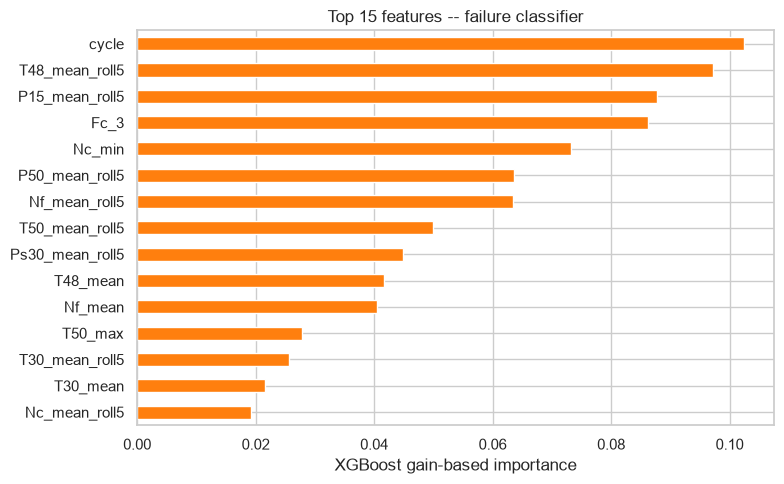

In [10]:
importances_clf = pd.Series(clf_model.feature_importances_, index=feature_columns()).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 5))
importances_clf.iloc[::-1].plot.barh(ax=ax, color="tab:orange")
ax.set_xlabel("XGBoost gain-based importance")
ax.set_title("Top 15 features -- failure classifier")
plt.tight_layout()
plt.show()

## Summary

| Framing | Split | Metric | Value |
|---|---|---|---|
| RUL regression | test | RMSE | see table above |
| RUL regression | test | PHM08 mean score | see table above |
| Failure classification (\u226420 cycles) | test | precision / recall / F1 | see table above |

Numbers are read directly from the tables above at notebook run time -- not restated by
hand here, so this cell never drifts out of sync with the actual run.